In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

### Loading Dataset

In [143]:
wine_data = pd.read_csv('wine_quality.csv')

### Check how the data is distributed

In [144]:
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Information about the data columns

In [145]:
wine_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [146]:
wine_data['quality'].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

### How the data columns are distributed?

### Distribution of quality labels

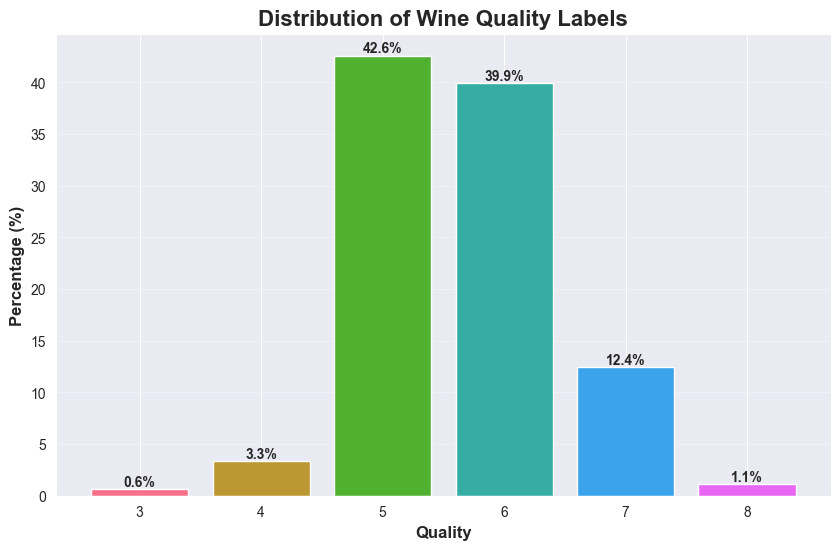

In [147]:
quality_counts = wine_data['quality'].value_counts().sort_index()

quality_percentages = (quality_counts / quality_counts.sum()) * 100

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(quality_percentages.index, quality_percentages.values, 
               color=sns.color_palette('husl', len(quality_percentages)))

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontweight='bold')

plt.xlabel('Quality', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.title('Distribution of Wine Quality Labels', fontsize=16, fontweight='bold')
plt.xticks(quality_percentages.index)
plt.grid(axis='y', alpha=0.3)
plt.show()

<Axes: xlabel='quality', ylabel='fixed acidity'>

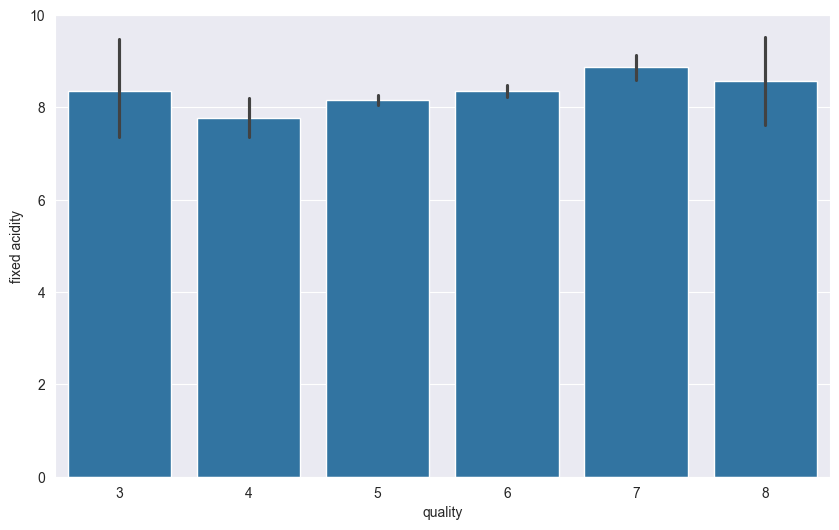

In [148]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'fixed acidity', data = wine_data)


`Fixed acity does not give any specification to classify the quality`

<Axes: xlabel='quality', ylabel='volatile acidity'>

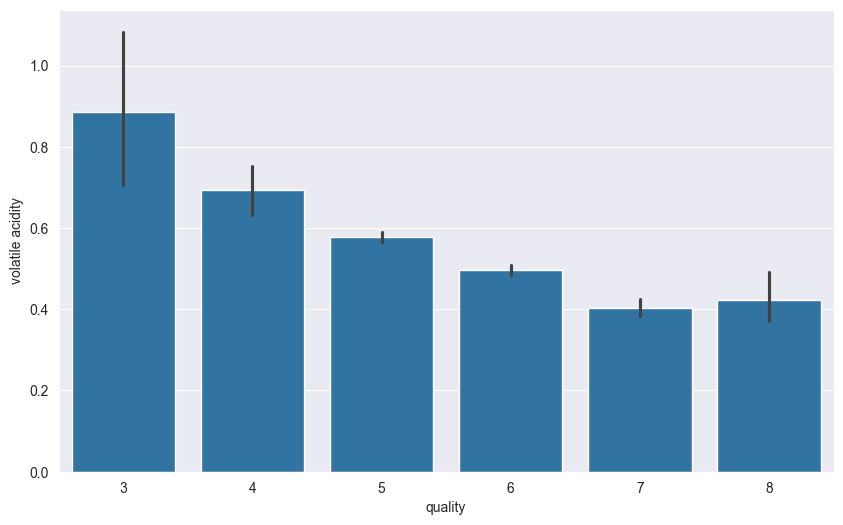

In [149]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'volatile acidity', data = wine_data)


`Quite a downing trend in the volatile acidy as we go higher the quality`

<Axes: xlabel='quality', ylabel='citric acid'>

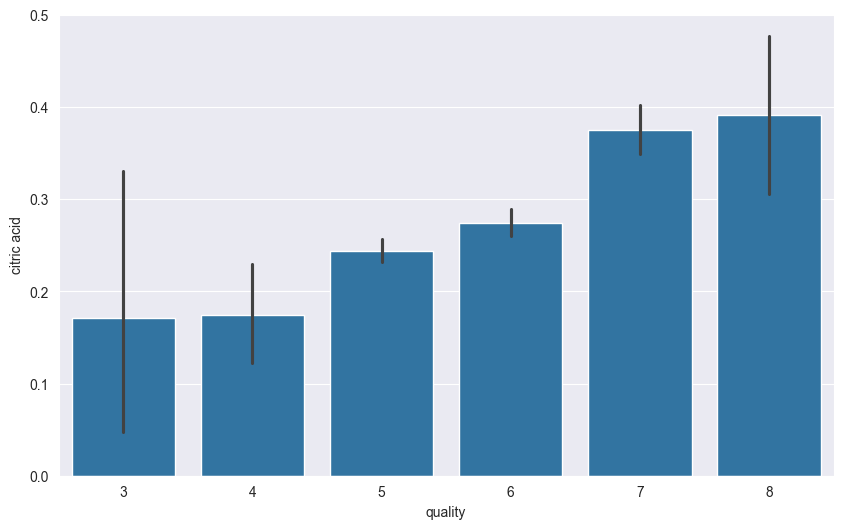

In [150]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'citric acid', data = wine_data)


`Citric acid go higher as we go higher in the quality of the wine`

<Axes: xlabel='quality', ylabel='residual sugar'>

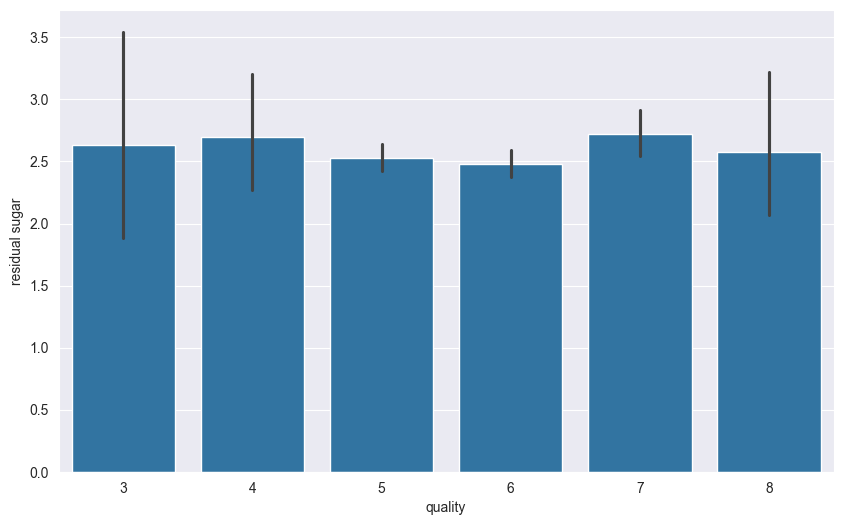

In [151]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'residual sugar', data = wine_data)


`Residual sugar does not give any specification to classify the quality`

<Axes: xlabel='quality', ylabel='chlorides'>

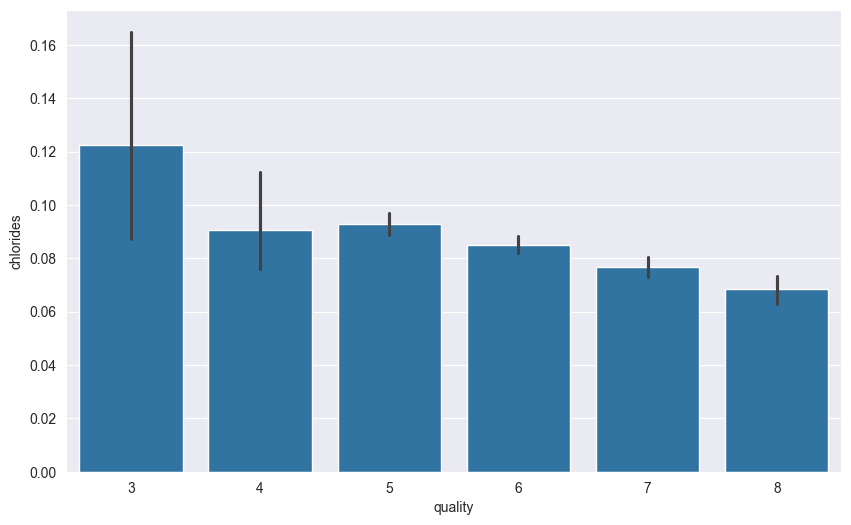

In [152]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'chlorides', data = wine_data)


`Composition of chloride also go down as we go higher in the quality of the wine`

<Axes: xlabel='quality', ylabel='free sulfur dioxide'>

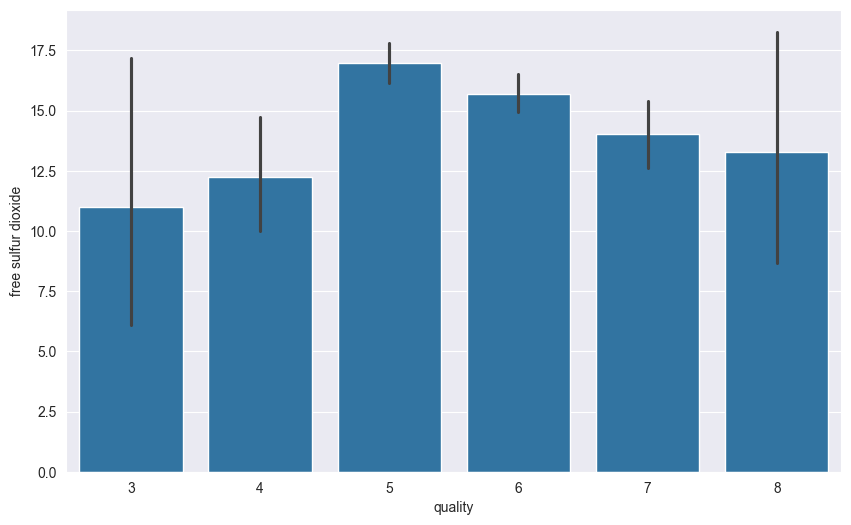

In [153]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'free sulfur dioxide', data = wine_data)


<Axes: xlabel='quality', ylabel='total sulfur dioxide'>

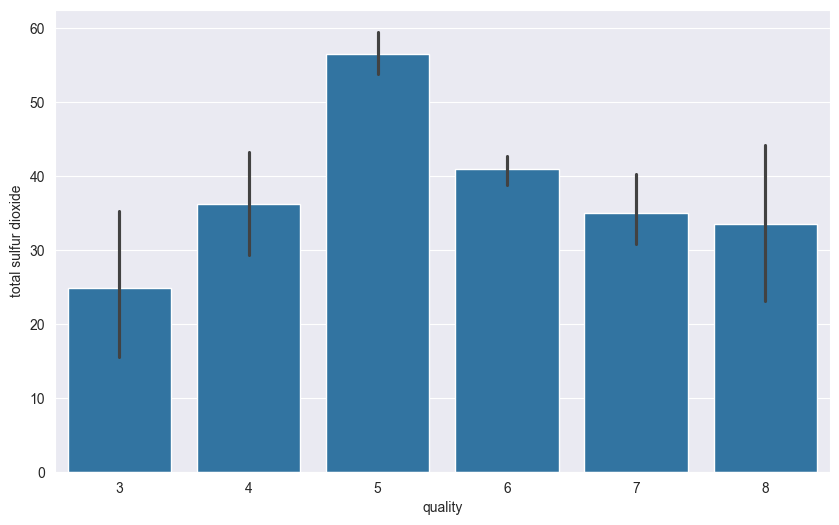

In [154]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'total sulfur dioxide', data = wine_data)


<Axes: xlabel='quality', ylabel='density'>

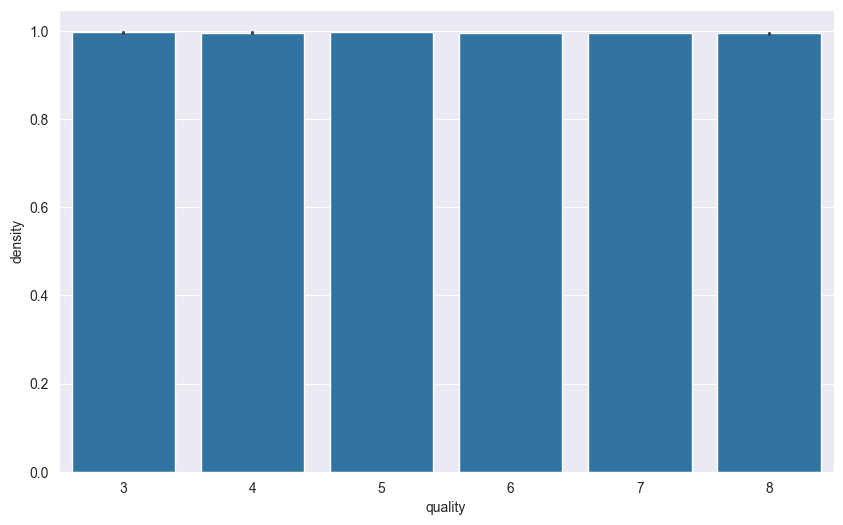

In [155]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'density', data = wine_data)


<Axes: xlabel='quality', ylabel='pH'>

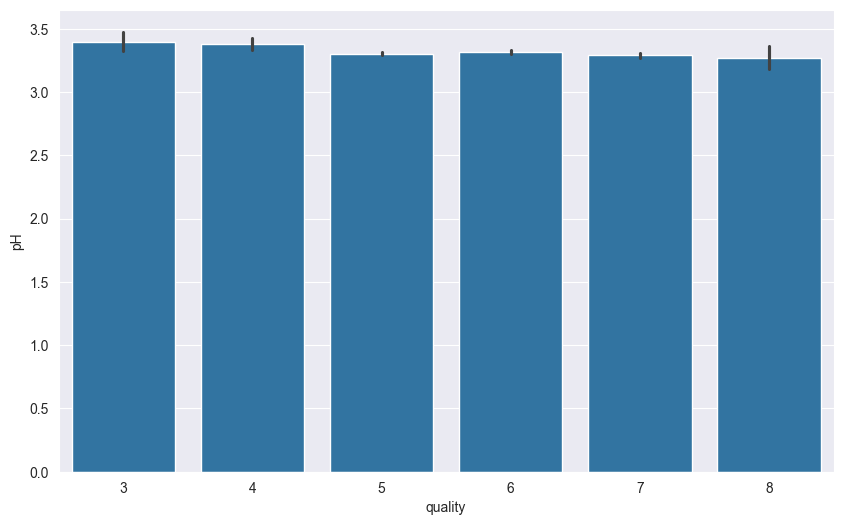

In [156]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'pH', data = wine_data)


<Axes: xlabel='quality', ylabel='sulphates'>

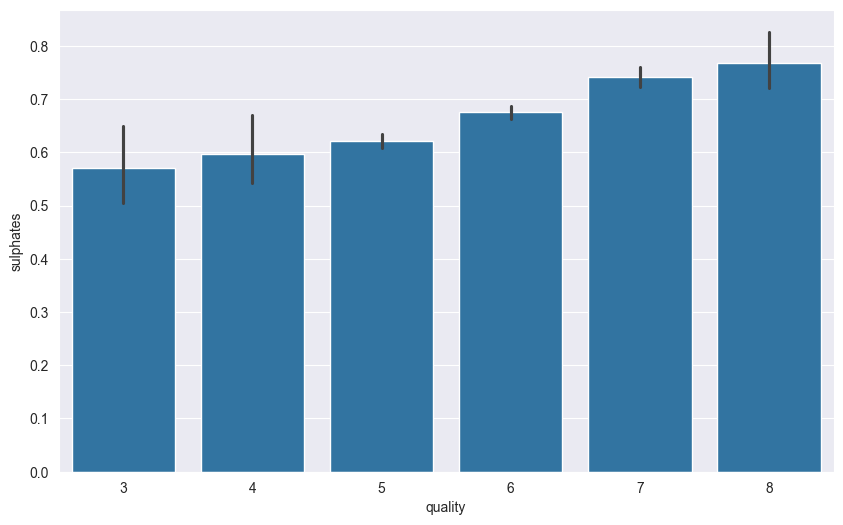

In [157]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'sulphates', data = wine_data)


`Sulphates level goes higher with the quality of wine`

<Axes: xlabel='quality', ylabel='alcohol'>

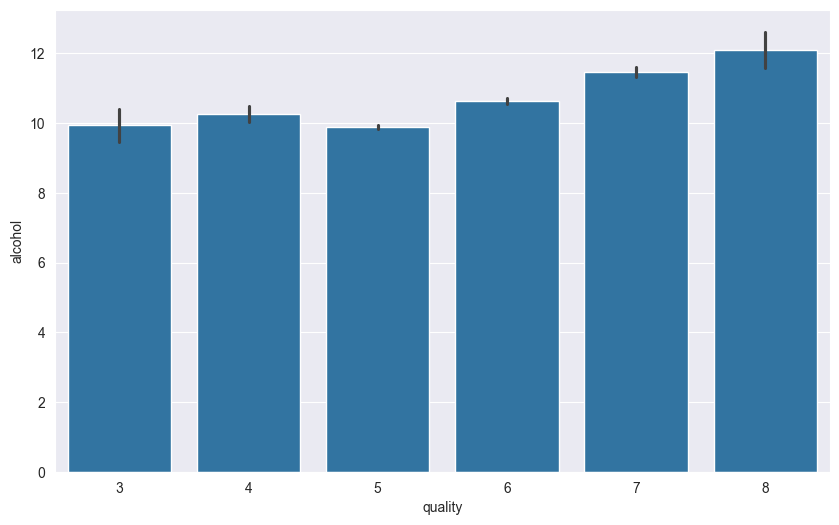

In [158]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'alcohol', data = wine_data)


`Alcohol level also goes higher as te quality of wine increases`

#### Process Data

In [159]:
wine_data_bi=wine_data.copy()

# 1. Criar a classificação binária baseada na regra:
# quality <= 5 -> 'under-average'
# quality >= 6 -> 'above-average'
wine_data_bi['Target'] = wine_data_bi['quality'].apply(lambda x: 1 if x >= 6 else 0)

wine_data_bi=wine_data_bi.drop(columns=['quality'])

wine_data_bi.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


## Missing values e linhas duplicadas

In [160]:
print("Missing values por coluna:\n")
print(wine_data.isna().sum())

print("\nTotal de missing values no dataset:", wine_data.isna().sum().sum())

print("\nTotal de linhas duplicadas:")
print(wine_data.duplicated().sum())

#apagar duplicados
#wine_data = wine_data.drop_duplicates()







Missing values por coluna:

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total de missing values no dataset: 0

Total de linhas duplicadas:
240


In [161]:
wine_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


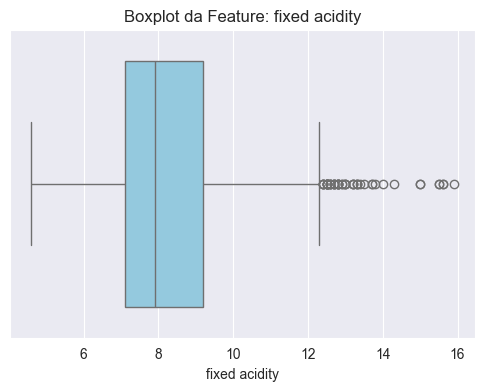

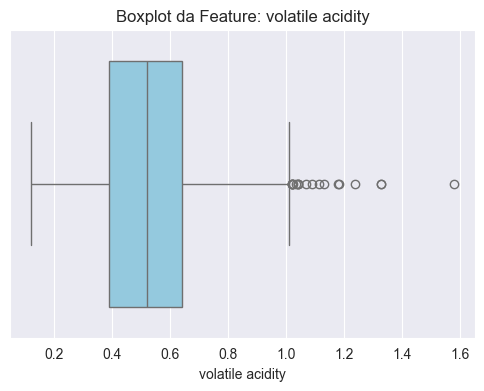

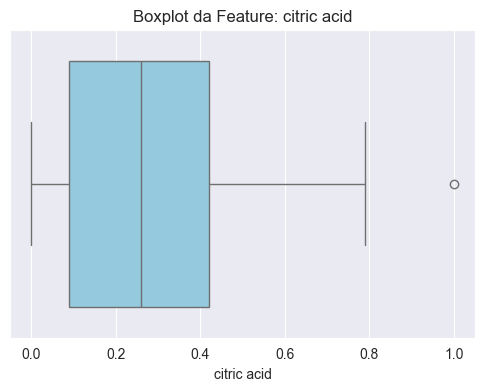

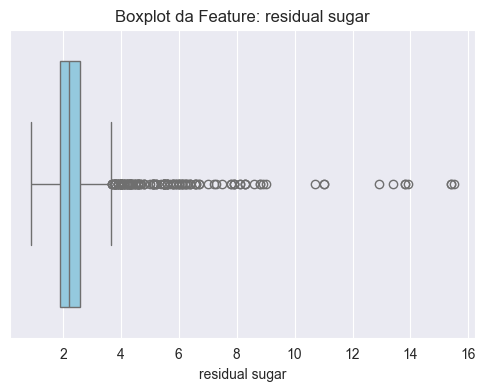

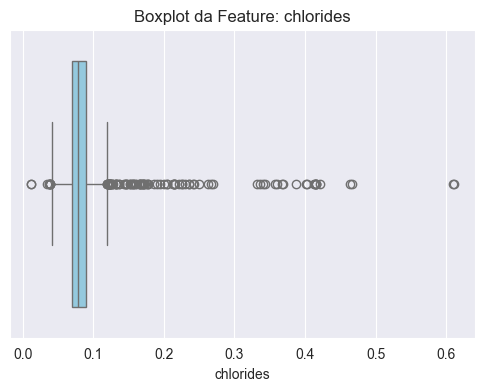

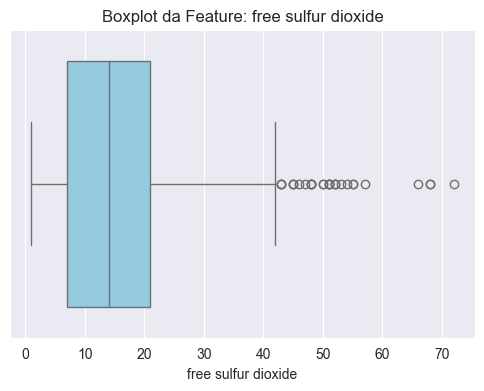

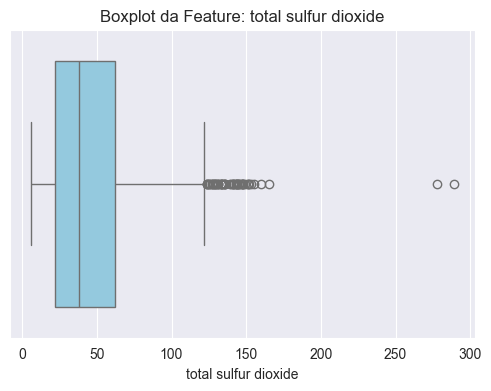

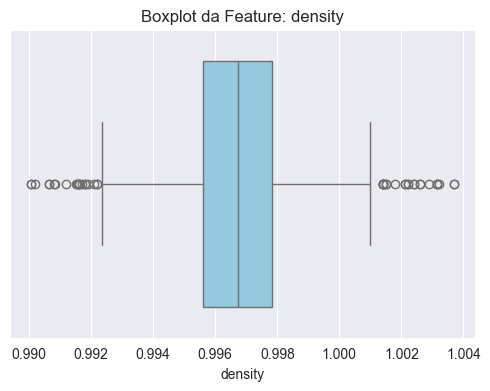

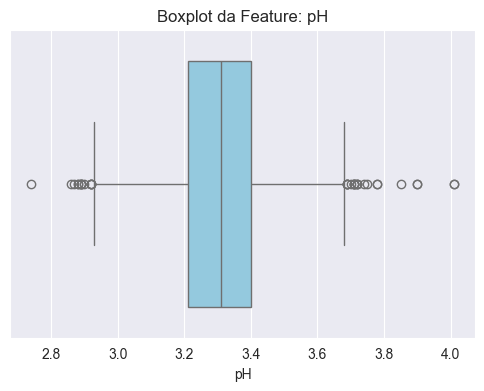

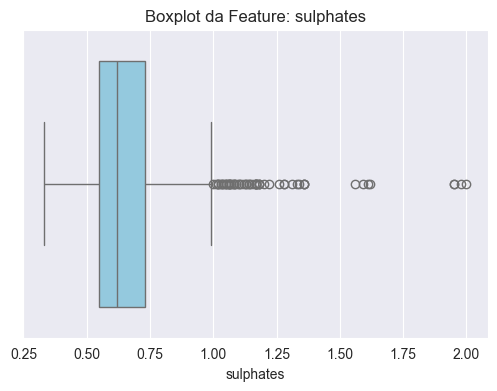

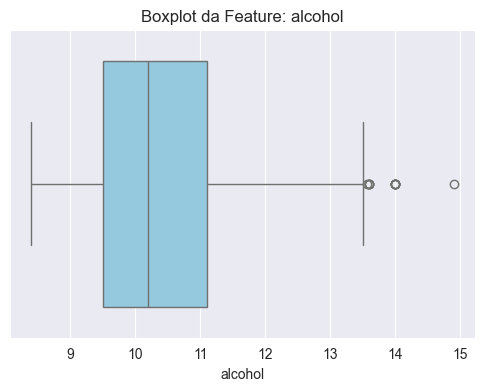

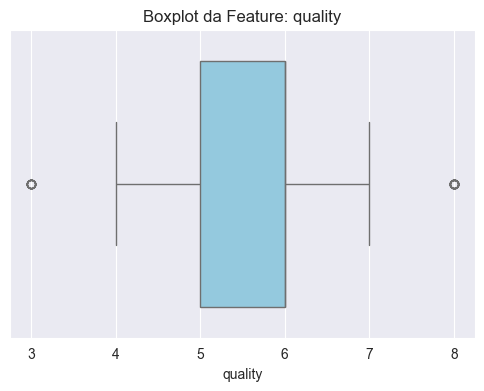

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in wine_data.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=wine_data[col], color='skyblue')
    plt.title(f"Boxplot da Feature: {col}")
    plt.xlabel(col)
    plt.show()



In [163]:
import pandas as pd
import numpy as np

outlier_summary = []

for col in wine_data.columns:
    if wine_data[col].dtype != 'object':  # só colunas numéricas

        Q1 = wine_data[col].quantile(0.25)
        Q3 = wine_data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # mascara para outliers
        outliers = wine_data[(wine_data[col] < lower_bound) | (wine_data[col] > upper_bound)]
        num_outliers = outliers.shape[0]
        total = wine_data.shape[0]
        perc_outliers = (num_outliers / total) * 100

        outlier_summary.append([col, num_outliers, total, perc_outliers])

# Criar DataFrame final
outlier_df = pd.DataFrame(outlier_summary,
                          columns=["Feature", "Nº Outliers", "Total", "Percentagem (%)"])

# Ordenar da variável com mais outliers para a com menos
outlier_df = outlier_df.sort_values(by="Percentagem (%)", ascending=False)

outlier_df


,Feature,Nº Outliers,Total,Percentagem (%)
3,residual sugar,155,1599,9.693558
4,chlorides,112,1599,7.004378
9,sulphates,59,1599,3.689806
6,total sulfur dioxide,55,1599,3.439650
0,fixed acidity,49,1599,3.064415
7,density,45,1599,2.814259
8,pH,35,1599,2.188868
5,free sulfur dioxide,30,1599,1.876173
11,quality,28,1599,1.751094
1,volatile acidity,19,1599,1.188243


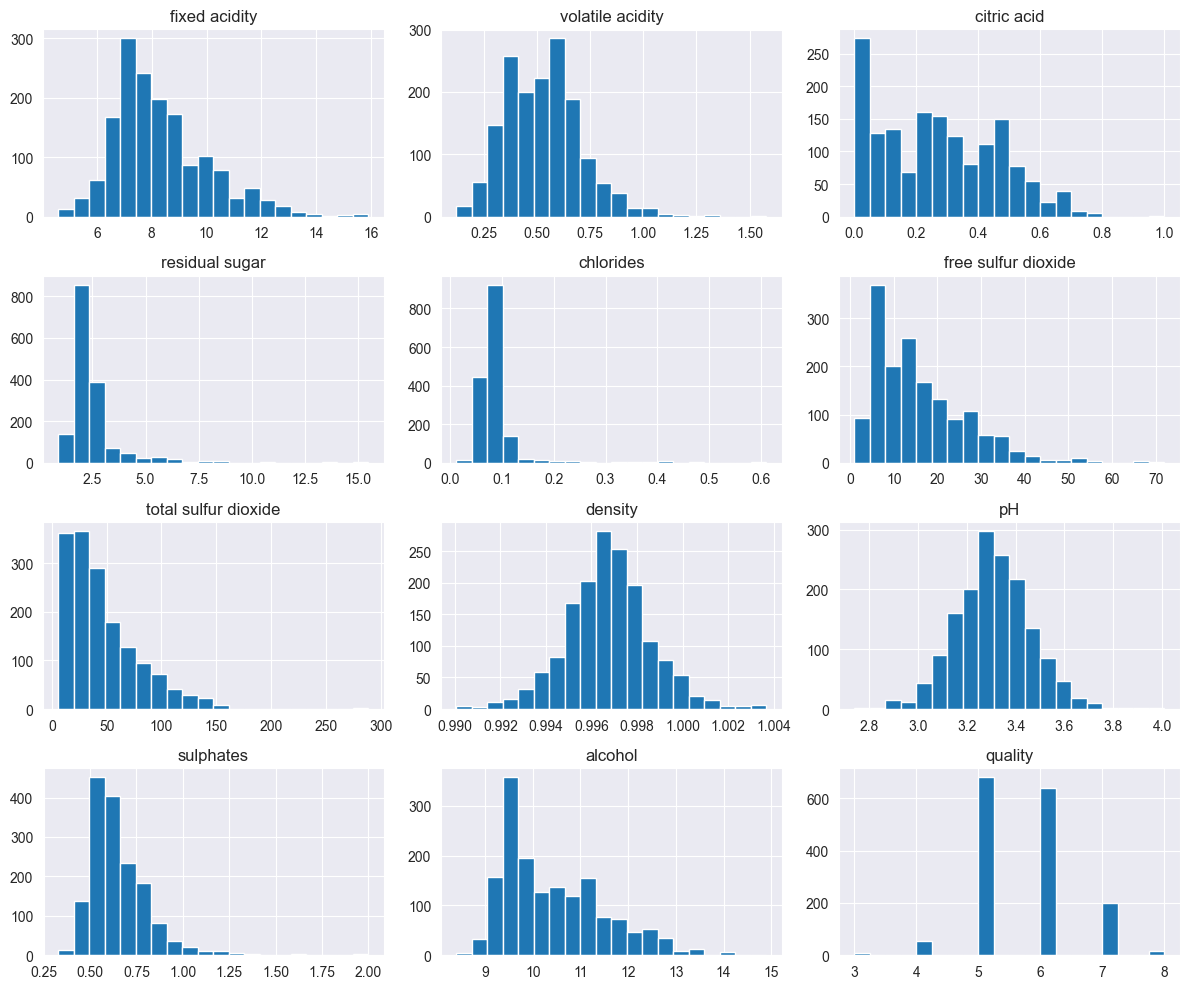

In [164]:
wine_data.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()


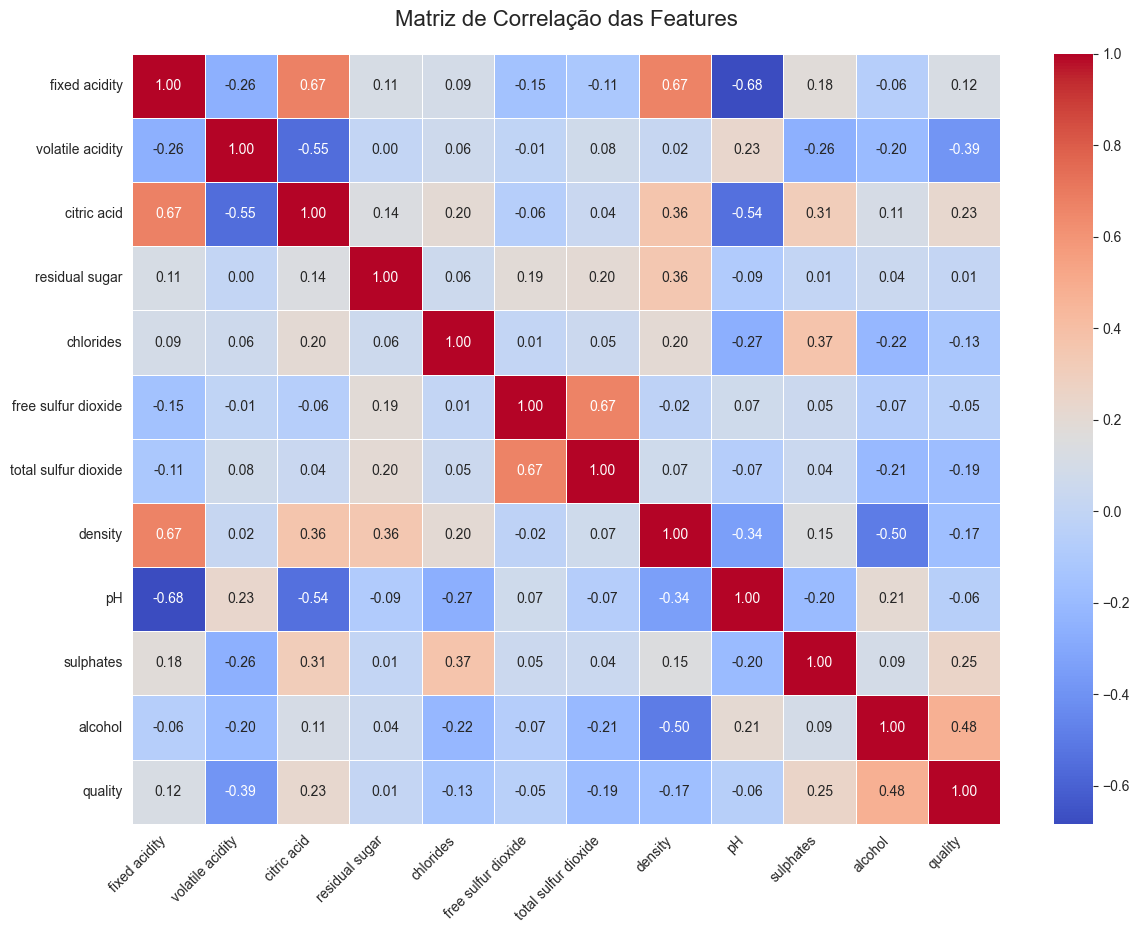

In [165]:
plt.figure(figsize=(14,10))

sns.heatmap(
    wine_data.corr(),
    annot=True,            # mostra valores
    fmt=".2f",             # 2 casas decimais
    cmap="coolwarm",       # mapa de cores perceptível
    linewidths=0.5,        # linhas entre células
    annot_kws={"size": 10} # tamanho do texto
)

plt.title("Matriz de Correlação das Features", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

